In [1]:
import pandas as pd
data=pd.read_parquet('TrainData/Train.parquet')

## Mô hình hồi quy Logistic

Kích thước tập X (Đặc trưng): (4504473, 14)
Kích thước tập y (Mục tiêu): (4504473,)

Đang tiến hành chuẩn hóa dữ liệu (Standardization)...

Đang huấn luyện thử nghiệm sự hội tụ của thuật toán (Max Iter: 1 -> 200)...


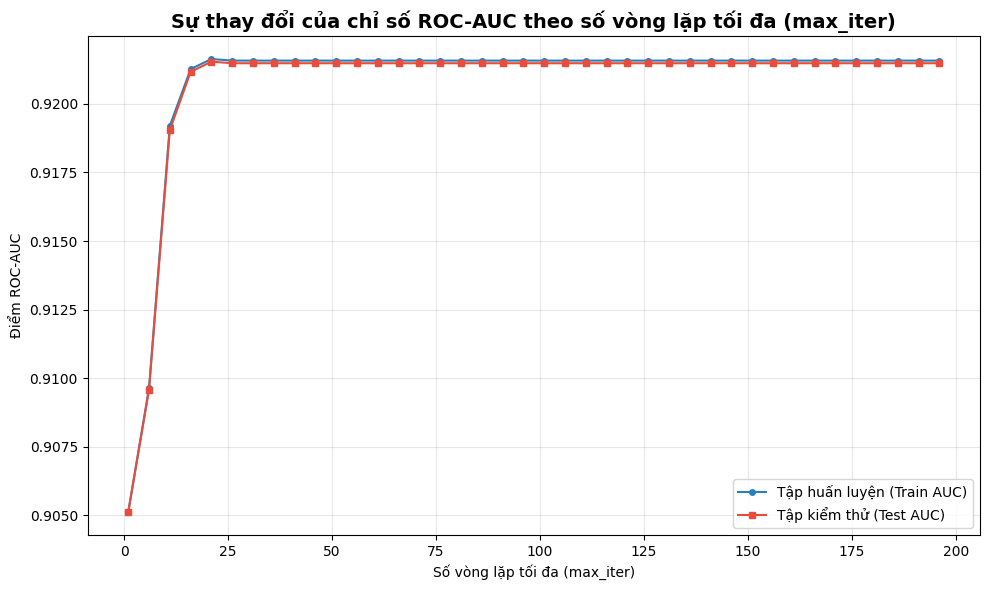


Đang huấn luyện mô hình chính thức với max_iter = 200...
 BÁO CÁO KẾT QUẢ: MÔ HÌNH HỒI QUY LOGISTIC 
              precision    recall  f1-score   support

           0       0.99      0.83      0.91    872934
           1       0.14      0.85      0.24     27961

    accuracy                           0.83    900895
   macro avg       0.57      0.84      0.57    900895
weighted avg       0.97      0.83      0.89    900895

Điểm ROC-AUC Score: 0.9215



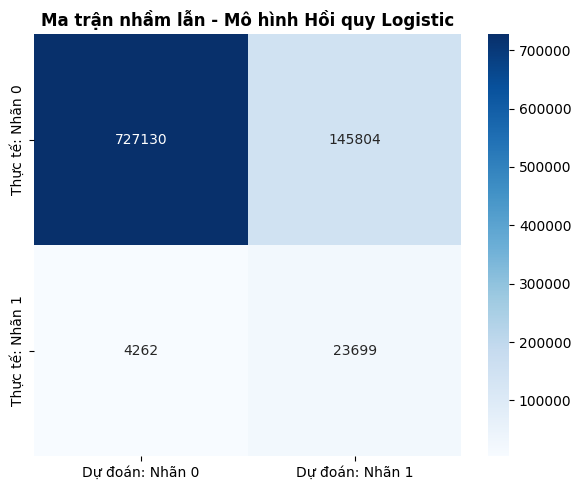

In [3]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning

# Ẩn cảnh báo chưa hội tụ ở các vòng lặp thấp
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Loại bỏ các đặc trưng định danh, RFM thô và các biến gây đa cộng tuyến
cols_to_drop = [
    'user_session', 'user_id', 
    'Frequency', 'Monetary', 'Recency', 
    'avg_price', 'max_price' 
]
df_ml = data.drop(columns=cols_to_drop, errors='ignore')

# Khởi tạo không gian đặc trưng (X) và biến mục tiêu (y)
X = df_ml.drop(columns=['is_purchased'])
y = df_ml['is_purchased']

print(f"Kích thước tập X (Đặc trưng): {X.shape}")
print(f"Kích thước tập y (Mục tiêu): {y.shape}\n")

# =====================================================================
# 2. PHÂN CHIA TẬP DỮ LIỆU VÀ CHUẨN HÓA
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Đang tiến hành chuẩn hóa dữ liệu (Standardization)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 3. THỬ NGHIỆM SỐ VÒNG LẶP (MAX_ITER) VÀ VẼ ĐỒ THỊ ROC-AUC
# =====================================================================
print("\nĐang huấn luyện thử nghiệm sự hội tụ của thuật toán (Max Iter: 1 -> 200)...")

# Khởi tạo danh sách lưu trữ kết quả
iter_range = list(range(1, 201, 5)) # Chạy thử các mốc: 1, 6, 11, 16... đến 200
train_auc_scores = []
test_auc_scores = []

for i in iter_range:
    # Huấn luyện mô hình với số vòng lặp i
    model_temp = LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=i, 
        solver='lbfgs' # Bộ giải thuật tiêu chuẩn
    )
    model_temp.fit(X_train_scaled, y_train)
    
    # Dự đoán xác suất
    prob_train = model_temp.predict_proba(X_train_scaled)[:, 1]
    prob_test = model_temp.predict_proba(X_test_scaled)[:, 1]
    
    # Tính điểm ROC-AUC
    train_auc_scores.append(roc_auc_score(y_train, prob_train))
    test_auc_scores.append(roc_auc_score(y_test, prob_test))

# --- Vẽ đồ thị đánh giá sự hội tụ ---
plt.figure(figsize=(10, 6))
plt.plot(iter_range, train_auc_scores, label='Tập huấn luyện (Train AUC)', marker='o', markersize=4, color='#2980b9')
plt.plot(iter_range, test_auc_scores, label='Tập kiểm thử (Test AUC)', marker='s', markersize=4, color='#e74c3c')

plt.title('Sự thay đổi của chỉ số ROC-AUC theo số vòng lặp tối đa (max_iter)', fontweight='bold', fontsize=14)
plt.xlabel('Số vòng lặp tối đa (max_iter)')
plt.ylabel('Điểm ROC-AUC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. HUẤN LUYỆN MÔ HÌNH CHÍNH THỨC (Với max_iter = 200)
# =====================================================================
print("\nĐang huấn luyện mô hình chính thức với max_iter = 200...")
model_lr_final = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
model_lr_final.fit(X_train_scaled, y_train)

# Dự đoán và Đánh giá
y_pred_final = model_lr_final.predict(X_test_scaled)
y_prob_final = model_lr_final.predict_proba(X_test_scaled)[:, 1]

print("=====================================================")
print(" BÁO CÁO KẾT QUẢ: MÔ HÌNH HỒI QUY LOGISTIC ")
print("=====================================================")
print(classification_report(y_test, y_pred_final))

roc_auc_final = roc_auc_score(y_test, y_prob_final)
print(f"Điểm ROC-AUC Score: {roc_auc_final:.4f}")
print("=====================================================\n")

# =====================================================================
# 5. TRỰC QUAN HÓA MA TRẬN NHẦM LẪN
# =====================================================================
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán: Nhãn 0', 'Dự đoán: Nhãn 1'],
            yticklabels=['Thực tế: Nhãn 0', 'Thực tế: Nhãn 1'])
plt.title('Ma trận nhầm lẫn - Mô hình Hồi quy Logistic', fontweight='bold')
plt.tight_layout()
plt.show()

Đóng gói mô hình

In [6]:
import joblib
joblib.dump(model_lr_final, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

['standard_scaler.pkl']

## Mô hình cây quyết định


Đang thiết lập không gian siêu tham số để tối ưu hóa...
Đang tiến hành tìm kiếm ngẫu nhiên (Randomized Search)... Vui lòng đợi!
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 TỐI ƯU HÓA THÀNH CÔNG! 
Bộ siêu tham số tối ưu nhất tìm được:
 - min_samples_split: 500
 - min_samples_leaf: 500
 - max_depth: 12
 - criterion: entropy

Đang đánh giá mô hình trên tập kiểm thử...

BÁO CÁO KẾT QUẢ PHÂN LOẠI:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    872934
           1       0.23      0.96      0.37     27961

    accuracy                           0.90    900895
   macro avg       0.61      0.93      0.66    900895
weighted avg       0.97      0.90      0.93    900895

Điểm ROC-AUC Score: 0.9671


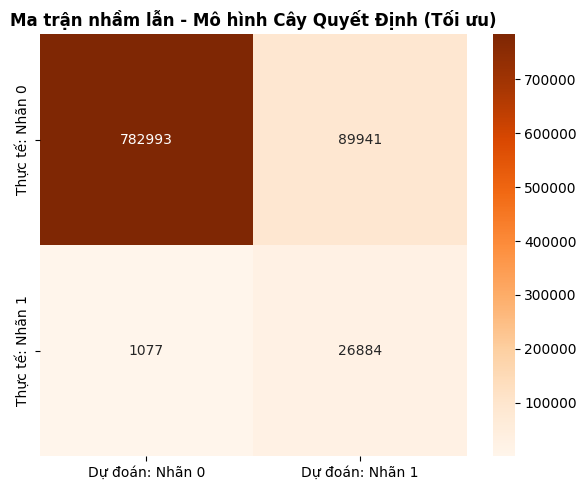

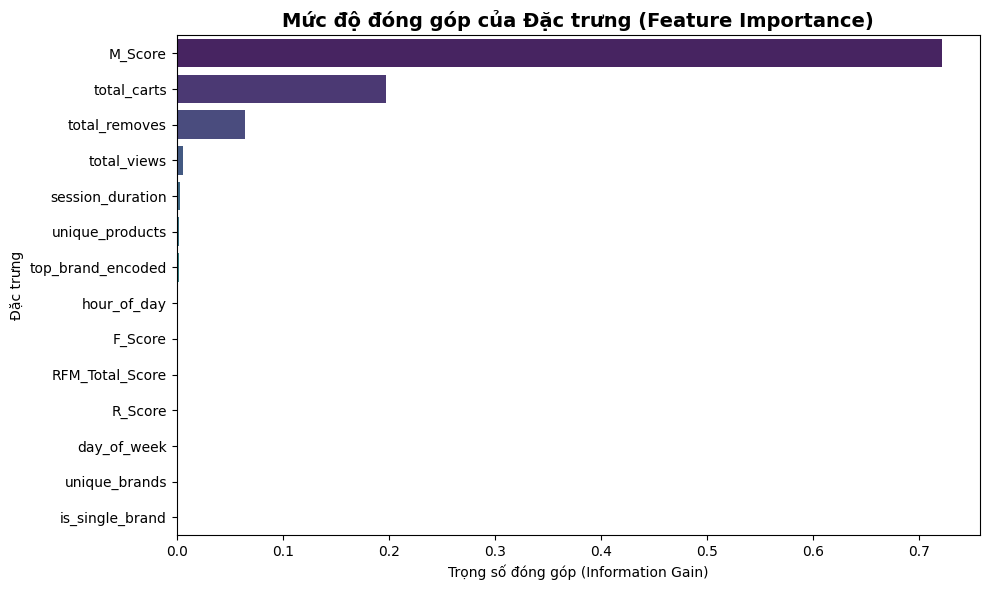

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')


# Loại bỏ các đặc trưng định danh, RFM thô và biến gây đa cộng tuyến
cols_to_drop = [
    'user_session', 'user_id', 
    'Frequency', 'Monetary', 'Recency', 
    'avg_price', 'max_price' 
]
df_ml = data.drop(columns=cols_to_drop, errors='ignore')

# Tách Đặc trưng (X) và Nhãn mục tiêu (y)
X = df_ml.drop(columns=['is_purchased'])
y = df_ml['is_purchased']

# Chia tập Train/Test (Lưu ý: Không cần dùng StandardScaler cho Decision Tree)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# 2. THIẾT LẬP KHÔNG GIAN SIÊU THAM SỐ VÀ TỐI ƯU HÓA
# =====================================================================
print("\nĐang thiết lập không gian siêu tham số để tối ưu hóa...")

# Khởi tạo mô hình cơ sở với cơ chế cân bằng nhãn
base_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Định nghĩa không gian tìm kiếm siêu tham số
param_distributions = {
    'criterion': ['gini', 'entropy'],           # Tiêu chuẩn chia nhánh
    'max_depth': [5, 8, 12, 15, 20],            # Chiều sâu tối đa (Tránh Overfitting)
    'min_samples_split': [100, 500, 1000],      # Số mẫu tối thiểu để rẽ nhánh tiếp
    'min_samples_leaf': [50, 200, 500]          # Số mẫu tối thiểu phải có ở nút lá cuối cùng
}

# Sử dụng RandomizedSearchCV để tối ưu hóa (Tập trung tối ưu ROC-AUC)
print("Đang tiến hành tìm kiếm ngẫu nhiên (Randomized Search)... Vui lòng đợi!")
random_search = RandomizedSearchCV(
    estimator=base_tree,
    param_distributions=param_distributions,
    n_iter=10,             # Thử nghiệm 10 tổ hợp tham số ngẫu nhiên
    scoring='roc_auc',     # Mục tiêu tối ưu là điểm ROC-AUC
    cv=3,                  # Đánh giá chéo 3 folds (Cross-validation)
    n_jobs=-1,             # Sử dụng toàn bộ lõi CPU để tăng tốc
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

# Trích xuất mô hình tốt nhất
best_tree_model = random_search.best_estimator_

print("\n=====================================================")
print(" TỐI ƯU HÓA THÀNH CÔNG! ")
print("=====================================================")
print("Bộ siêu tham số tối ưu nhất tìm được:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")
print("=====================================================\n")

# =====================================================================
# 3. DỰ ĐOÁN VÀ ĐÁNH GIÁ MÔ HÌNH TỐI ƯU
# =====================================================================
print("Đang đánh giá mô hình trên tập kiểm thử...")
y_pred_tree = best_tree_model.predict(X_test)
y_prob_tree = best_tree_model.predict_proba(X_test)[:, 1]

roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("\nBÁO CÁO KẾT QUẢ PHÂN LOẠI:")
print(classification_report(y_test, y_pred_tree))
print(f"Điểm ROC-AUC Score: {roc_auc_tree:.4f}")

# =====================================================================
# 4. TRỰC QUAN HÓA MA TRẬN NHẦM LẪN VÀ FEATURE IMPORTANCE
# =====================================================================
# Biểu đồ 1: Ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Dự đoán: Nhãn 0', 'Dự đoán: Nhãn 1'],
            yticklabels=['Thực tế: Nhãn 0', 'Thực tế: Nhãn 1'])
plt.title('Ma trận nhầm lẫn - Mô hình Cây Quyết Định (Tối ưu)', fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ 2: Mức độ quan trọng của đặc trưng (Feature Importance)
importances = best_tree_model.feature_importances_
df_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Mức độ đóng góp của Đặc trưng (Feature Importance)', fontweight='bold', fontsize=14)
plt.xlabel('Trọng số đóng góp (Information Gain)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

In [7]:

print("Đang đóng gói mô hình Cây quyết định...")
joblib.dump(best_tree_model, 'decision_tree_optimal_model.pkl')


Đang đóng gói mô hình Cây quyết định...


['decision_tree_optimal_model.pkl']

## Mô hình Random Forest

--- BƯỚC 1: TỐI ƯU HÓA SIÊU THAM SỐ CHO RỪNG NGẪU NHIÊN ---
Đang chạy RandomizedSearchCV (Quá trình này có thể mất vài phút)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

[ KẾT QUẢ TỐI ƯU HÓA ]
Bộ cấu hình tốt nhất tìm được:
 - n_estimators: 100
 - min_samples_split: 100
 - min_samples_leaf: 20
 - max_features: sqrt
 - max_depth: 20

--- BƯỚC 2: TÌM NGƯỠNG QUYẾT ĐỊNH VÀ ĐÁNH GIÁ MÔ HÌNH ---
Điểm ROC-AUC Score: 0.9683
Chỉ số Youden's J cực đại: 0.8602
Ngưỡng quyết định tối ưu: 0.4352

BÁO CÁO PHÂN LOẠI (TẠI NGƯỠNG TỐI ƯU):
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    872934
           1       0.24      0.96      0.38     27961

    accuracy                           0.90    900895
   macro avg       0.62      0.93      0.66    900895
weighted avg       0.97      0.90      0.93    900895


--- BƯỚC 3: XUẤT BIỂU ĐỒ ĐÁNH GIÁ ---


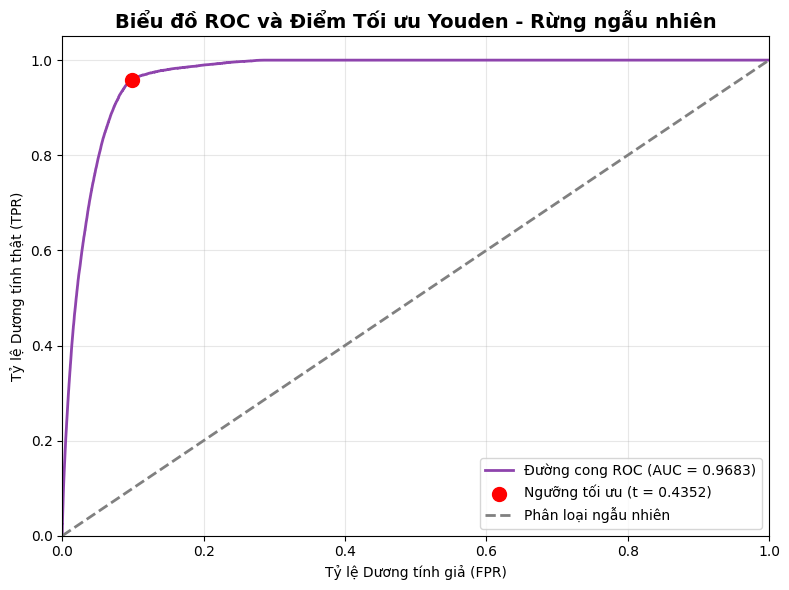

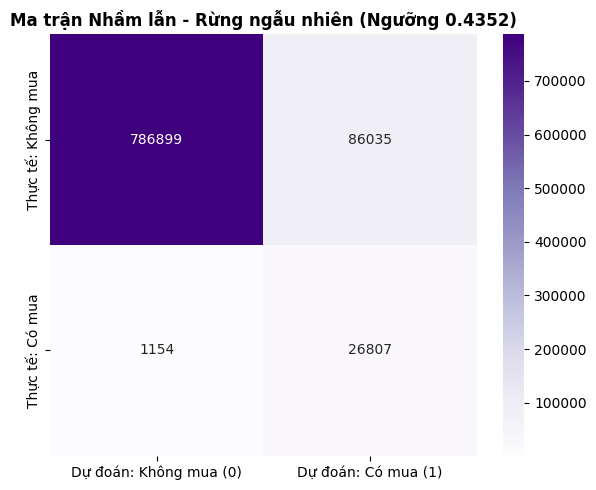

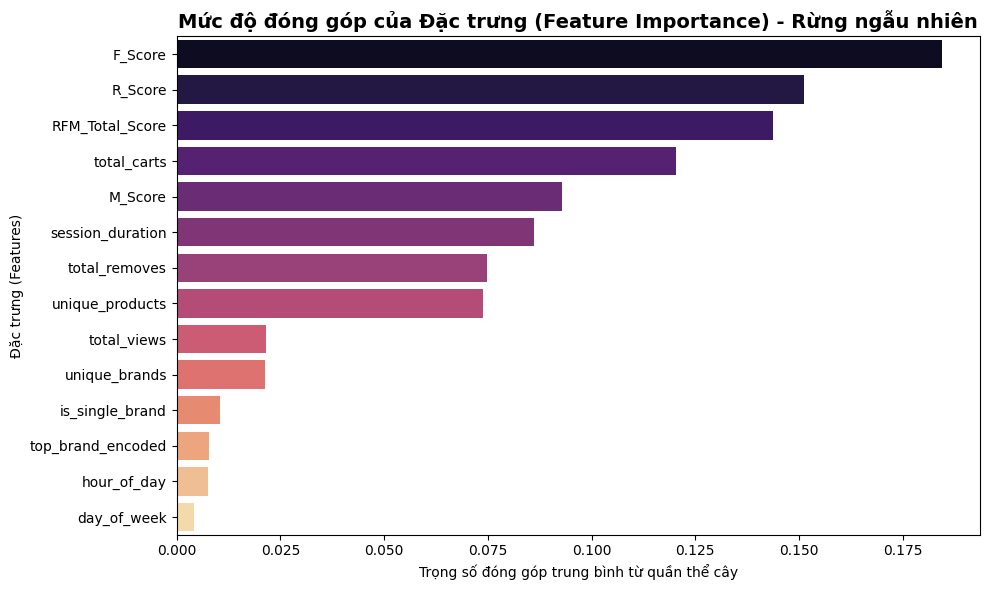

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Ghi chú: Giả định bạn đã có X_train, X_test, y_train, y_test từ bước chia dữ liệu ban đầu.
# Thuật toán Rừng ngẫu nhiên KHÔNG YÊU CẦU dùng StandardScaler.

# =====================================================================
# 1. THIẾT LẬP VÀ TỐI ƯU HÓA KHÔNG GIAN SIÊU THAM SỐ
# =====================================================================
print("--- BƯỚC 1: TỐI ƯU HÓA SIÊU THAM SỐ CHO RỪNG NGẪU NHIÊN ---")

# Khởi tạo mô hình cơ sở với cơ chế cân bằng trọng số và dùng đa luồng (n_jobs=-1)
base_rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

# Thiết lập không gian tìm kiếm (bao gồm các giá trị bạn đã chốt)
param_distributions_rf = {
    'n_estimators': [50, 100, 200],              
    'max_depth': [10, 15, 20],                   
    'min_samples_split': [100, 300, 500],        
    'min_samples_leaf': [20, 50, 100],           
    'max_features': ['sqrt', 'log2']             
}

print("Đang chạy RandomizedSearchCV (Quá trình này có thể mất vài phút)...")
random_search_rf = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions_rf,
    n_iter=10,             # Thử nghiệm 10 tổ hợp ngẫu nhiên
    scoring='roc_auc',     # Tối ưu hóa dựa trên diện tích dưới đường cong ROC
    cv=3,                  # Đánh giá chéo 3 nếp gấp (3-fold CV)
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train, y_train)
best_rf_model = random_search_rf.best_estimator_

print("\n[ KẾT QUẢ TỐI ƯU HÓA ]")
print("Bộ cấu hình tốt nhất tìm được:")
for param, value in random_search_rf.best_params_.items():
    print(f" - {param}: {value}")

# =====================================================================
# 2. DỰ ĐOÁN VÀ TÌM NGƯỠNG TỐI ƯU BẰNG YOUDEN'S J
# =====================================================================
print("\n--- BƯỚC 2: TÌM NGƯỠNG QUYẾT ĐỊNH VÀ ĐÁNH GIÁ MÔ HÌNH ---")
# Dự đoán xác suất cho Nhãn 1
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Lấy dữ liệu đường cong ROC để tính J
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Tính mảng Youden's J và trích xuất ngưỡng tối ưu
J_scores_rf = tpr_rf - fpr_rf
best_idx_rf = np.argmax(J_scores_rf)
best_threshold_rf = thresholds_rf[best_idx_rf]
best_J_rf = J_scores_rf[best_idx_rf]

# Phân loại lại nhãn dựa trên ngưỡng tối ưu vừa tìm
y_pred_rf_optimal = (y_prob_rf >= best_threshold_rf).astype(int)

print(f"Điểm ROC-AUC Score: {roc_auc_rf:.4f}")
print(f"Chỉ số Youden's J cực đại: {best_J_rf:.4f}")
print(f"Ngưỡng quyết định tối ưu: {best_threshold_rf:.4f}\n")

print("BÁO CÁO PHÂN LOẠI (TẠI NGƯỠNG TỐI ƯU):")
print(classification_report(y_test, y_pred_rf_optimal))

# =====================================================================
# 3. TRỰC QUAN HÓA KẾT QUẢ BẰNG BIỂU ĐỒ
# =====================================================================
print("\n--- BƯỚC 3: XUẤT BIỂU ĐỒ ĐÁNH GIÁ ---")

# --- Biểu đồ 1: Đường cong ROC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='#8e44ad', lw=2, label=f'Đường cong ROC (AUC = {roc_auc_rf:.4f})')
plt.scatter(fpr_rf[best_idx_rf], tpr_rf[best_idx_rf], marker='o', color='red', s=100, zorder=5, 
            label=f'Ngưỡng tối ưu (t = {best_threshold_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Phân loại ngẫu nhiên')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (FPR)')
plt.ylabel('Tỷ lệ Dương tính thật (TPR)')
plt.title('Biểu đồ ROC và Điểm Tối ưu Youden - Rừng ngẫu nhiên', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Ma trận nhầm lẫn ---
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf_optimal)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Dự đoán: Không mua (0)', 'Dự đoán: Có mua (1)'],
            yticklabels=['Thực tế: Không mua', 'Thực tế: Có mua'])
plt.title(f'Ma trận Nhầm lẫn - Rừng ngẫu nhiên (Ngưỡng {best_threshold_rf:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Mức độ quan trọng của Đặc trưng ---
importances_rf = best_rf_model.feature_importances_
df_importance_rf = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance_rf, x='Importance', y='Feature', palette='magma')
plt.title('Mức độ đóng góp của Đặc trưng (Feature Importance) - Rừng ngẫu nhiên', fontweight='bold', fontsize=14)
plt.xlabel('Trọng số đóng góp trung bình từ quần thể cây')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

In [11]:
joblib.dump(best_rf_model,'random_fr.pkl')

['random_fr.pkl']

LightGBM

--- BƯỚC 1: TỐI ƯU HÓA SIÊU THAM SỐ CHO LIGHTGBM ---
Đang chạy RandomizedSearchCV cho LightGBM (Rất nhanh nhờ kiến trúc Leaf-wise)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 74563, number of negative: 2327822
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Number of data points in the train set: 2402385, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

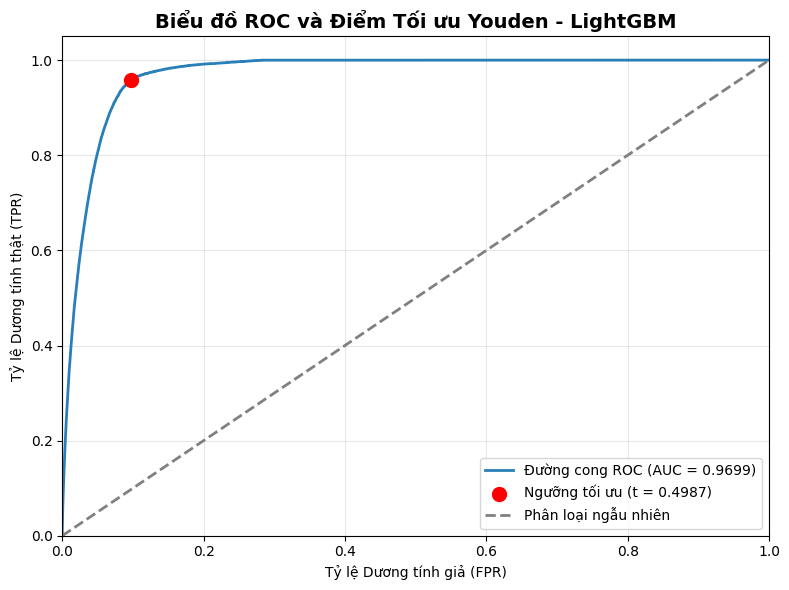

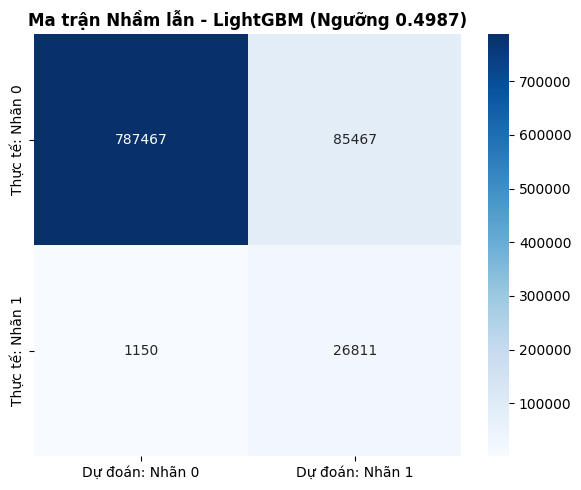

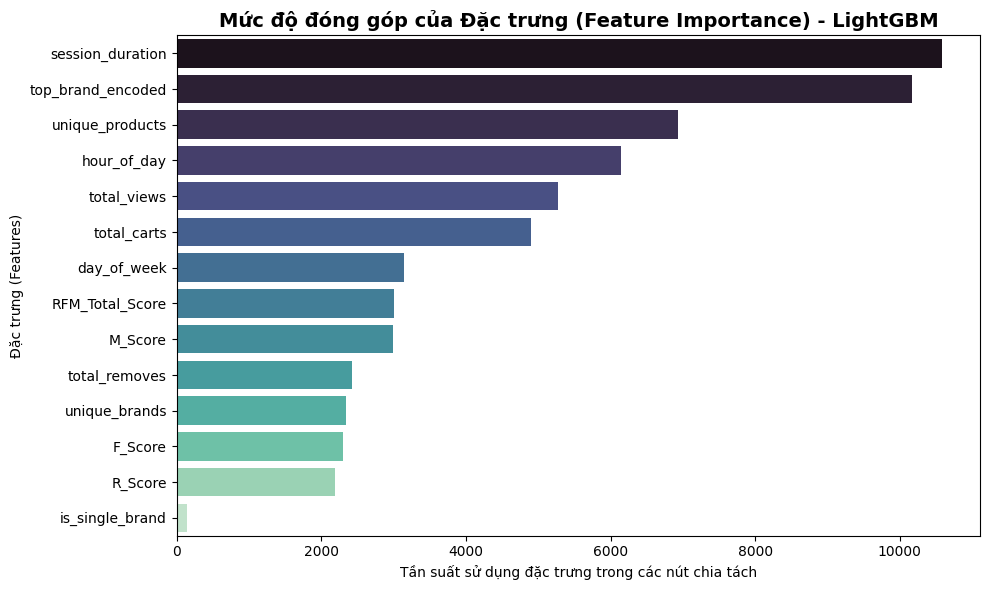

In [12]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. THIẾT LẬP VÀ TỐI ƯU HÓA KHÔNG GIAN SIÊU THAM SỐ CHO LIGHTGBM
# =====================================================================
print("--- BƯỚC 1: TỐI ƯU HÓA SIÊU THAM SỐ CHO LIGHTGBM ---")

# Khởi tạo mô hình cơ sở của LightGBM
base_lgb = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Thiết lập không gian tìm kiếm (Bao gồm các con số tối ưu bạn đã cung cấp)
param_distributions_lgb = {
    'n_estimators': [200, 300, 420, 500],
    'learning_rate': [0.01, 0.0274, 0.05, 0.1],
    'max_depth': [8, 10, 13, 15],
    'num_leaves': [100, 150, 186, 256],
    'min_child_samples': [100, 150, 205, 300],
    'subsample': [0.7, 0.8, 0.88, 1.0],
    'colsample_bytree': [0.7, 0.79, 0.9, 1.0]
}

print("Đang chạy RandomizedSearchCV cho LightGBM (Rất nhanh nhờ kiến trúc Leaf-wise)...")
random_search_lgb = RandomizedSearchCV(
    estimator=base_lgb,
    param_distributions=param_distributions_lgb,
    n_iter=15,             # Thử nghiệm 15 tổ hợp ngẫu nhiên
    scoring='roc_auc',     # Tối ưu hóa ROC-AUC
    cv=3,                  # Đánh giá chéo 3 nếp gấp
    random_state=42,
    verbose=1
)

random_search_lgb.fit(X_train, y_train)
best_lgb_model = random_search_lgb.best_estimator_

print("\n[ KẾT QUẢ TỐI ƯU HÓA ]")
print("Bộ cấu hình tốt nhất tìm được cho LightGBM:")
for param, value in random_search_lgb.best_params_.items():
    print(f" - {param}: {value}")

# =====================================================================
# 2. DỰ ĐOÁN VÀ TÌM NGƯỠNG TỐI ƯU BẰNG YOUDEN'S J
# =====================================================================
print("\n--- BƯỚC 2: TÌM NGƯỠNG QUYẾT ĐỊNH VÀ ĐÁNH GIÁ MÔ HÌNH ---")
y_prob_lgb = best_lgb_model.predict_proba(X_test)[:, 1]

# Tính ROC và Youden's J
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_prob_lgb)
roc_auc_lgb = roc_auc_score(y_test, y_prob_lgb)

J_scores_lgb = tpr_lgb - fpr_lgb
best_idx_lgb = np.argmax(J_scores_lgb)
best_threshold_lgb = thresholds_lgb[best_idx_lgb]
best_J_lgb = J_scores_lgb[best_idx_lgb]

# Áp dụng ngưỡng tối ưu
y_pred_lgb_optimal = (y_prob_lgb >= best_threshold_lgb).astype(int)

print(f"Điểm ROC-AUC Score: {roc_auc_lgb:.4f}")
print(f"Chỉ số Youden's J cực đại: {best_J_lgb:.4f}")
print(f"Ngưỡng quyết định tối ưu: {best_threshold_lgb:.4f}\n")

print("BÁO CÁO PHÂN LOẠI (TẠI NGƯỠNG TỐI ƯU):")
print(classification_report(y_test, y_pred_lgb_optimal))

# =====================================================================
# 3. TRỰC QUAN HÓA BẰNG BIỂU ĐỒ
# =====================================================================
print("\n--- BƯỚC 3: XUẤT BIỂU ĐỒ ĐÁNH GIÁ ---")

# --- Biểu đồ 1: Đường cong ROC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, color='#2980b9', lw=2, label=f'Đường cong ROC (AUC = {roc_auc_lgb:.4f})')
plt.scatter(fpr_lgb[best_idx_lgb], tpr_lgb[best_idx_lgb], marker='o', color='red', s=100, zorder=5, 
            label=f'Ngưỡng tối ưu (t = {best_threshold_lgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Phân loại ngẫu nhiên')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (FPR)')
plt.ylabel('Tỷ lệ Dương tính thật (TPR)')
plt.title('Biểu đồ ROC và Điểm Tối ưu Youden - LightGBM', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Ma trận nhầm lẫn ---
plt.figure(figsize=(6, 5))
cm_lgb = confusion_matrix(y_test, y_pred_lgb_optimal)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán: Nhãn 0', 'Dự đoán: Nhãn 1'],
            yticklabels=['Thực tế: Nhãn 0', 'Thực tế: Nhãn 1'])
plt.title(f'Ma trận Nhầm lẫn - LightGBM (Ngưỡng {best_threshold_lgb:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Mức độ quan trọng của Đặc trưng ---
importances_lgb = best_lgb_model.feature_importances_
df_importance_lgb = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances_lgb
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance_lgb, x='Importance', y='Feature', palette='mako')
plt.title('Mức độ đóng góp của Đặc trưng (Feature Importance) - LightGBM', fontweight='bold', fontsize=14)
plt.xlabel('Tần suất sử dụng đặc trưng trong các nút chia tách')
plt.ylabel('Đặc trưng (Features)')
plt.tight_layout()
plt.show()

In [15]:
joblib.dump(best_lgb_model,'lgb_model')

['lgb_model']